In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy
import sympy as sp
import pandas as pd

In [ ]:

def p(r):
  return np.pi*2*r

def a(r):
  return np.pi*r**2

def v(r):
  return 1.333333333333333333333333333333333333333333333333333333333333333333333333333333*(np.pi*r**3)

def fact(n):
  t = 1
  for i in range(2,n+1):
    t *= i
  return t

In [ ]:
p(5)

31.41592653589793

In [ ]:
a(5)

78.53981633974483

In [ ]:
v(5)

523.5987755982987

In [ ]:
fact(1500)

4811997796779774860166990093581379781834808040672613808130855941163057518900109559129223058520673385186846400961934358519405209112461816627027148188139333143162796281029984414933378904468939551048716787976932530369947046782923439926332654565286074860507574636692832360664549227754112008343808672736937788767600021140531848024435420741960486417696995058143522219885119456898409570594554958905456832179233891914944298591995773479295940249909684564302040186938117560396442433322211412597437481780424263330976980429395287003461935412501421004564766406324016200756010866529056864612834255714735098535872415462325337186747076512042207386796393577525869210975304176209434356905049747035353176448150317475091185823090699836106608478775831611058573601336537743186073857226132573823365683527194735269518086557304383402795553901276548937264504250440659775235748193153287235663541122457833404052229474640282958545847870877834637943186236882481900917709144403488594139431934391022316865586976179966907505952760850

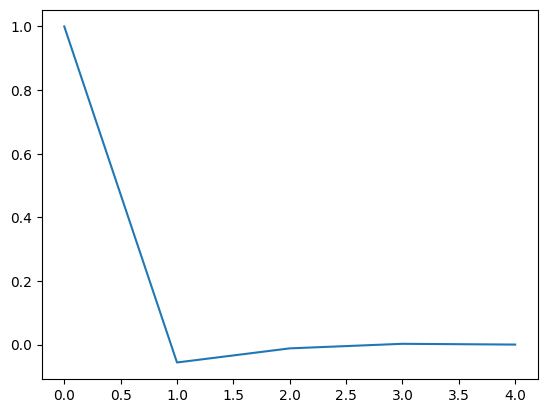

In [ ]:
equis = [i * 1.00001 for i in range(5)]
vals = []
for i in range(len(equis)):
  vals.append(math.cos(2*i)*np.e**(-2*i))

plt.plot(equis, vals)

In [ ]:
x =  61.4946
xgo = 61.3
Ea = abs(x -xgo)
Er = Ea / abs(x)

print(Ea)
print(Er)



0.19460000000000122
0.0031645055012960686


In [ ]:
x =  0.005421
xgo = 0.100
Ea = abs(x -xgo)
Er = Ea / abs(x)

print(Ea)
print(Er)

0.09457900000000001
17.446781036709098


In [ ]:
x1 = 8.110

x2 = -18.11

y1 = 12.20

y2 = 112.2

r1 = 0.1370

r2 = -0.1376

# Clase #3 (creo), Series de Taylor

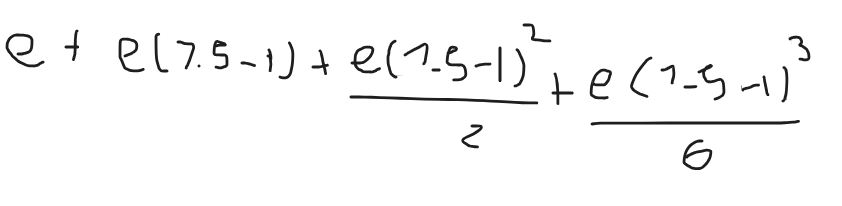



In [ ]:

def a(x):
  return np.e + np.e * (x - 1) + (np.e*(x-1)**2)/2 + (np.e*(x - 1)**3)/6


print(a(1.5))
print(a(5))
print(a(10))

4.473838842672179
64.3326699401974
467.5444744949558


In [ ]:
print(np.e**(1.5))
print(np.e**(5))
print(np.e**(10))

4.4816890703380645
148.41315910257657
22026.465794806703


In [ ]:
def Taylor(function:str, Point:float, NumTerms:int, value:float):
  r:int = 0
  for k in range(0, NumTerms+1):
    differentiate = sp.diff(function, x, k)
    eval = differentiate.evalf(subs={x:Point})
    r += (eval*(x-Point)**k)/math.factorial(k)

  return r.subs(x, value)


In [ ]:
x = sp.symbols('x')
fn = sp.exp(x)/x


a = Taylor(fn, 1, 20, )




3.75000000000000

In [ ]:
type(a)

b = float(a)

In [ ]:
np.e**1.5

4.4816890703380645

# Ejercicio

Calcular el polinomio de grado 2 para la función $f(x)=e^{x}\sin (x)$ entonco a $x_0=0$. Hallar
1. P(0.5), P(4), P(4.5)
2. Determine la cota del error $R_2(0.5)$
3. Realice una grafica del polinomio construido versus la función
4. Determine una aproximación para $f'(0.5)$
5. Determine una aproximación para $\int_{0}^{0.5} f(x)dx $

In [ ]:
x = sp.symbols('x')
fn = sp.exp(x)*sp.sin(x)


a = Taylor(fn, 2, 0, x)

In [ ]:
2*  ((0.5)**3)/6

0.041666666666666664

In [ ]:
Ea = abs(x -a)
Er = Ea / abs(x)

print(Ea)
print(Er)


In [ ]:

def evaluacion (funcion, polinomio, x_puntos):
  f=sp. lambdify(x, funcion)
  P=sp.lambdify(x, polinomio)
  datos=[]
  for i in x_puntos:
    datos.append([i, f(i), P(i), abs(f(i)-P(i)), abs((f(i)-P(i))/f(i))])
  D=pd.DataFrame(data=datos, columns=['x', 'valor_Verd=f(x)', 'valor_aprox=P(x)', 'E_a', 'E_r'])
  print (D)
  return
evaluacion(fn, a, [0.5,4,4.5])


     x  valor_Verd=f(x)  valor_aprox=P(x)         E_a       E_r
0  0.5         0.790439              0.75    0.040439  0.051160
1  4.0       -41.320016             20.00   61.320016  1.484027
2  4.5       -87.994457             24.75  112.744457  1.281268


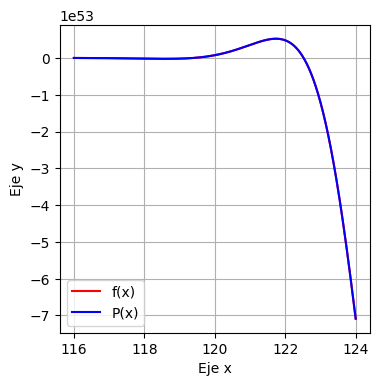

In [ ]:

def grafica (funcion, polinomio, xo):
  f=sp.lambdify(x, funcion)
  P=sp.lambdify(x, polinomio)
  delta=4
  x_values=np.linspace (xo-delta, xo+delta, 1000)
  plt.figure(figsize=(4,4))
  plt.plot(x_values, f(x_values), 'r', label='f(x)')
  plt.plot(x_values, P(x_values), 'b', label='P(x)')
  plt.xlabel('Eje x')
  plt.ylabel('Eje y')
  plt.legend()
  plt.grid()
  return


grafica(fn,a,120)

In [ ]:

def cota_truncamiento (f, grado,xo,x_point):
  dfn=sp.diff(f,x, grado+1)
  de=sp. lambdify(x,dfn)
  m=min(xo, x_point)
  M=max(xo,x_point)
  x_array=np.linspace (m, M, 1000)
  Maximo=max(abs (de (x_array)))
  cota=Maximo*abs(x_point-xo)** (grado+1)/math.factorial(grado+1)
  return cota
cota_truncamiento (fn, 2, 0,0.5)

np.float64(0.041666666666666664)